# **Assignment 2- Perform Fuzzy K-means Clustering on Customer Segmentation dataset**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


## **1. Import necessary libraries**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Download the Customer Segmentation dataset from kaggle**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fahmidachowdhury/customer-segmentation-data-for-marketing-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-data-for-marketing-analysis' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-data-for-marketing-analysis


## **3. Load the dataset**

In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
# List files in the downloaded directory to find the CSV file
file_list = os.listdir(path)
csv_file = None
for f in file_list:
    if f.lower().endswith('.csv'):
        csv_file = f
        break

if csv_file:
    full_file_path = os.path.join(path, csv_file)
    df = pd.read_csv(full_file_path)
    display(df.head())
else:
    print("Error: No CSV file found in the downloaded dataset directory.")

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


## **4. Perform Preprocessing and Fuzzy C-Means Clustering**

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical features
categorical_features = ['gender', 'preferred_category']
numerical_features = ['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like 'id') if any, or drop them
)

# Apply preprocessing to the dataframe
X_preprocessed = preprocessor.fit_transform(df.drop('id', axis=1)) # Drop 'id' as it's not a feature

print("Data preprocessing complete. Shape of preprocessed data (X_preprocessed):", X_preprocessed.shape)

# -------------------------------------------------------------------------------------------
# Install scikit-fuzzy if not already installed
!pip install -q scikit-fuzzy

import skfuzzy as fuzz

# Define the number of clusters (K)
n_clusters = 2

# Set parameters for Fuzzy C-Means
m = 2       # Fuzziness parameter (m > 1)
error = 0.005 # Termination criterion
maxiter = 1000 # Maximum number of iterations

# Transpose X_preprocessed if it's not in the correct format (samples x features)
# skfuzzy expects data as (features x samples)
data_for_fcm = X_preprocessed.T

# Perform Fuzzy C-Means clustering
cntr, u, u0, d, jm, p, fpc = fuzz.cmeans(
    data_for_fcm, n_clusters, m, error, maxiter, seed=42
)

# 'u' contains the membership degrees (n_clusters x n_samples)
# We need to transpose it to (n_samples x n_clusters) to append to X
membership_degrees = u.T

# Concatenate the original preprocessed features with the membership degrees
X_augmented = np.hstack((X_preprocessed, membership_degrees))

# For the SVM model, we need a 'y' (target variable). Since this is clustering,
# we'll create a placeholder binary y. In a real classification task, y would be
# actual labels. For this example, let's assign based on cluster membership.
# We can assign class 0 to samples primarily belonging to cluster 0 and class 1 to cluster 1.
# This is a simplification and would need actual labels for supervised learning.
y = np.argmax(membership_degrees, axis=1) # Assigns each sample to the cluster with highest membership

print(f"Fuzzy C-Means clustering performed with {n_clusters} clusters.")
print(f"Shape of membership degrees: {membership_degrees.shape}")
print(f"Shape of X_augmented (preprocessed_features + membership_degrees): {X_augmented.shape}")
print(f"Shape of placeholder y: {y.shape}")

Data preprocessing complete. Shape of preprocessed data (X_preprocessed): (1000, 14)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 43.2 MB/s eta 0:00:00
Fuzzy C-Means clustering performed with 2 clusters.
Shape of membership degrees: (1000, 2)
Shape of X_augmented (preprocessed_features + membership_degrees): (1000, 16)
Shape of placeholder y: (1000,)


## **5. Train SVM model**

**Reasoning**:

Now that the feature vectors have been augmented with the fuzzy C-means membership degrees, the next step is to train an SVM model using these enhanced features and the corresponding labels. This will allow us to assess the performance of the SVM with the added clustering information.



In [ ]:
from sklearn.svm import SVC

# Instantiate a linear SVM classifier
svm_model_linear_augmented = SVC(kernel='linear')

# Instantiate an RBF SVM classifier
svm_model_rbf_augmented = SVC(kernel='rbf')

# Train the SVM models with the augmented data
svm_model_linear_augmented.fit(X_augmented, y)
svm_model_rbf_augmented.fit(X_augmented, y)

print("SVM models trained successfully with augmented data.")

SVM models trained successfully with augmented data.


## **6. Evaluate SVM (with Fuzzy Kmeans) Performance**

**Reasoning**:

With the augmented SVM models successfully trained, the next crucial step is to evaluate their performance. This involves using the trained models to make predictions on the `X_augmented` data and then calculating the accuracy by comparing these predictions to the true labels `y`.



In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions on the augmented data
y_pred_linear_augmented = svm_model_linear_augmented.predict(X_augmented)
y_pred_rbf_augmented = svm_model_rbf_augmented.predict(X_augmented)

# Calculate accuracy
accuracy_linear_augmented = accuracy_score(y, y_pred_linear_augmented)
accuracy_rbf_augmented = accuracy_score(y, y_pred_rbf_augmented)

print(f"Linear SVM (Augmented) Model Accuracy: {accuracy_linear_augmented:.4f}")
print(f"RBF SVM (Augmented) Model Accuracy: {accuracy_rbf_augmented:.4f}")

Linear SVM (Augmented) Model Accuracy: 0.9950
RBF SVM (Augmented) Model Accuracy: 0.9900


In [ ]:
# Evaluate the model
accuracy_rbf_augmented = accuracy_score(y, y_pred_rbf_augmented)
precision_rbf_augmented = precision_score(y, y_pred_rbf_augmented, average='weighted')
recall_rbf_augmented = recall_score(y, y_pred_rbf_augmented, average='weighted')
f1_rbf_augmented = f1_score(y, y_pred_rbf_augmented, average='weighted')

# Print the calculated metrics
print("\nSVM Model (with Fuzzy kmeans) Performance:")
print(f"Accuracy: {accuracy_rbf_augmented:.4f}")
print(f"Precision (weighted): {precision_rbf_augmented:.4f}")
print(f"Recall (weighted): {recall_rbf_augmented:.4f}")
print(f"F1-Score (weighted): {f1_rbf_augmented:.4f}")
print()


SVM Model (with Fuzzy kmeans) Performance:
Accuracy: 0.9900
Precision (weighted): 0.9901
Recall (weighted): 0.9900
F1-Score (weighted): 0.9900



In [ ]:
# Generate a classification report
print("\nClassification Report for SVM Model (with fuzzy kmeans):\n")
print(classification_report(y, y_pred_rbf_augmented))


Classification Report for SVM Model (with fuzzy kmeans):

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       488
           1       0.98      1.00      0.99       512

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



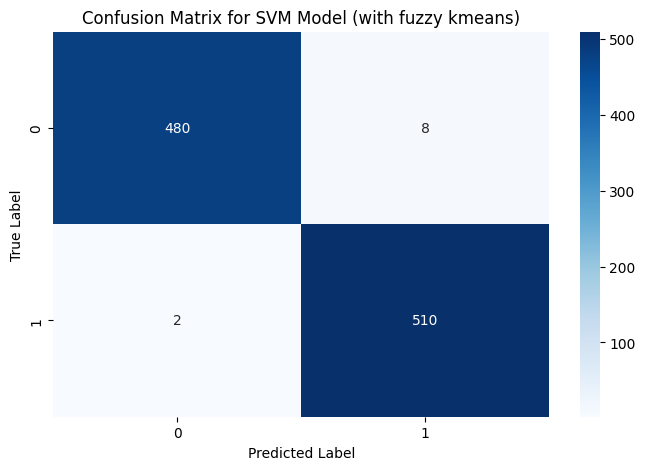

In [ ]:
# Generate and visualize a confusion matrix
cm_rbf_augmented = confusion_matrix(y, y_pred_rbf_augmented)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_rbf_augmented, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM Model (with fuzzy kmeans)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **7. Results of SVM (with Fuzzy Kmeans Clustering)**

**Model Metrics** -

* Accuracy: **0.9900**
* Precision (weighted): **0.9901**
* Recall (weighted): **0.9900**
* F1-Score (weighted): **0.9900**

---